# ch6_매개변수 갱신

## 1. 확률적 경사 하강법(SGD)

In [1]:
class SGD:
    def __init__(self, lr=0.01):
        self.lr = lr
        
    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[keys]

## 2. 모멘텀

In [2]:
class Momentum:
    def __init__(self, lr=0.01, momentum = 0.9):
        self.lr = lr
        self.momentum = momentum
        self.v = None
        
    def update(self, params, grads):
        if self.v is None:
            self.v = {}
            for key, val in params.items():
                self.v[key] = np.zeros_like(val)
                
        for key in params.keys():
            self.v[key] = self.momentum * self.v[key] - self.lr * grads[key]
            params[key] += self.v[key]

## 3. AdaGrad

In [3]:
class AdaGrad:
    def __init__(self, lr = 0.01):
        self.lr = lr
        self.h = None
        
    def update(self, params, grads):
        if self.h is None:
            self.h = {}
            for key, val in params.items():
                self.h[key] = np.zeros_like(val)
            
        for key in params.keys():
            self.h[key] += gards[key] * gards[key]
            params[key] -= self.lr * grads[key]/(np.sqrt(self.h[key])+1e-7)

## 4. 가중치의 초깃값
- 가중치의 초기값을 무엇으로 설정하느냐가 학습의 성패를 가름!
- 가중치 감소 기법 : 가중치의 매개변수 값이 작아지도록하여 오버피팅 방

### - 은닉층의 활성화값 분포

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1/(1+np.exp(-x))

x = np.random.randn(1000,100) #1000개의 데이터
node_num = 100 #각 은닉층의 노드 수
hidden_layer_size = 5 #총 5개의 은닉층
activations = {} #활성화 결과(활성화 값)을 저장

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]
        
    # w = np.random.randn(node_num, node_num) / np.sqrt(node_num) # -> 형태가 다소 일그러지지만 넓게 분포
                                                                 # -> 시그모이드 함수의 표현력도 제한받지 않고 학습이 효율적
    w = np.random.randn(node_num, node_num) * 0.01 # 가중치의 표준편차를 0.01로 바꿔 실
    a = np.dot(x,w)
    z = sigmoid(a)
    activations[i] = z

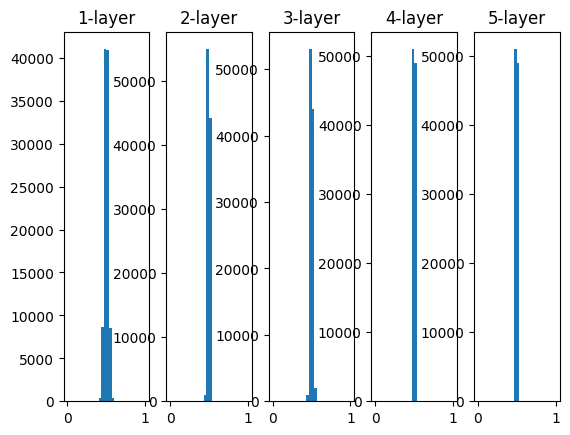

In [5]:
for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1)+"-layer")
    plt.hist(a.flatten(), 30, range = (0, 1))
plt.show()

층과 층 사이에 적당하게 다양한 데이터가 흐르게 해야 신경망 학습이 효율적으로 이루어 짐

### - 가중치 초기값 비교

===========iteration:0===========
std=0.01:2.3024582725683826
Xavier:2.302392443893019
He:2.3210363962686693
===========iteration:100===========
std=0.01:2.3016887464156697
Xavier:2.244917777283777
He:1.3071725441909807
===========iteration:200===========
std=0.01:2.303147431676039
Xavier:2.1927274788287026
He:0.7586924491080955
===========iteration:300===========
std=0.01:2.30062372778368
Xavier:1.895788009220555
He:0.46005231866581453
===========iteration:400===========
std=0.01:2.3033688782363795
Xavier:1.4261569024328082
He:0.40221500687702183
===========iteration:500===========
std=0.01:2.30378631892816
Xavier:0.947600476054062
He:0.3104130050203867
===========iteration:600===========
std=0.01:2.3002452719764532
Xavier:0.7711477737227846
He:0.2579621679218891
===========iteration:700===========
std=0.01:2.300651488603635
Xavier:0.6984367067544285
He:0.4484542645184065
===========iteration:800===========
std=0.01:2.3043947958358735
Xavier:0.4893651038361364
He:0.2608621909310147
==

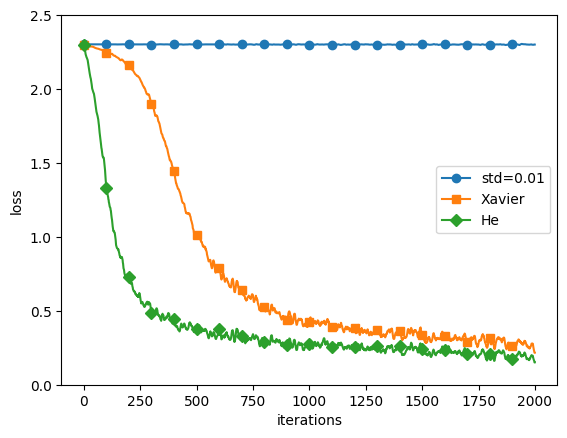

In [6]:
import os
import sys

sys.path.append(os.pardir) 
import numpy as np
import matplotlib.pyplot as plt
from mnist import load_mnist
from common.util import smooth_curve
from common.multi_layer_net import MultiLayerNet
from common.optimizer import SGD

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000

# 세 가지 가중치 초기값 설정
weight_init_types = {'std=0.01': 0.01, 'Xavier': 'sigmoid', 'He': 'relu'}
optimizer = SGD(lr=0.01)

networks = {}
train_loss = {}
for key, weight_type in weight_init_types.items():
    networks[key] = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100],
                                  output_size=10, weight_init_std=weight_type)
    train_loss[key] = []

for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    for key in weight_init_types.keys():
        grads = networks[key].gradient(x_batch, t_batch)
        optimizer.update(networks[key].params, grads)
    
        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)
    
    if i % 100 == 0:
        print("===========" + "iteration:" + str(i) + "===========")
        for key in weight_init_types.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + ":" + str(loss))


markers = {'std=0.01': 'o', 'Xavier': 's', 'He': 'D'}
x = np.arange(max_iterations)
for key in weight_init_types.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 2.5)
plt.legend()
plt.show()

## 결과 해석
### # std=0.01 (고정된 작은 값 초기화)
- 손실 값이 2.30 근처에서 거의 변화 없음
- 학습이 전혀 진행되지 않은 상태
- 그래디언트 소실(Vanishing Gradient) 현상이 심하게 발생

### # Xavier 초기화
- 처음엔 2.3에서 시작하지만, 점차 감소하여 1500회 이후 0.24~0.47 수준 유지
- 학습은 진행되지만 느림
- tanh나 sigmoid에 적합, ReLU엔 덜 효율적

### # He 초기화
- 손실이 빠르게 감소, 1000회 이전에 0.2 수준 이하 도달
- 가장 빠르고 안정적인 수렴 → ReLU 활성화 함수에 최적화된 초기화 방법

### - 오버피팅

In [7]:
import sys, os
sys.path.append(os.pardir)
from mnist import load_mnist
from common.multi_layer_net import MultiLayerNet
from common.optimizer import SGD

(x_train, t_train), (x_test, t_test) = load_mnist(normalize = True)

# 학습 데이터 수 줄임
x_train = x_train[:300]
t_train = t_train[:300]

In [8]:
network = MultiLayerNet(input_size = 784, hidden_size_list = [100,100,100,100,100,100], output_size = 10)
optimizer = SGD(lr = 0.01)
max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(10000000):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    grads =  network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)
    
    if i % iter_per_epoch == 0 :
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        
        epoch_cnt+= 1
        if epoch_cnt >= max_epochs:
            break

### - 드롭아웃

In [9]:
class Dropout:
    def __init__(self, dropout_ratio=0.5):
        self.dropout_ratio = dropout_ratio
        self.mask = None
        
    def forward(self, x, train_flg = True):
        if train_flg:
            self.mask = np.random.rand(*x.shape)>self.dropout_ration
            return x * self.mask
        else:
            return x * (1.0 - self.dropout_ratio)
        
    def backward(self, dout):
        return dout * self.mask

## 5. 적절한 하이퍼파라미터 값 찾기
### - 검증 데이터

In [10]:
import sys, os
sys.path.append(os.pardir)
from common.util import shuffle_dataset

(x_train, t_train), (x_test, t_test) = load_mnist()

x_train, t_train = shuffle_dataset(x_train, t_train)

#20%를 검증 데이터로 분할
validation_rate = 0.2
validation_num = int(x_train.shape[0] * validation_rate)

x_val = x_train[:validation_num]
t_val = t_train[:validation_num]
x_train = x_train[validation_num:]
t_train = t_train[validation_num:]